## About Me

Hi, I'm Malak Nashwan.

I am passionate about Data Science, Machine Learning, and data analysis. I enjoy working with real-world datasets, cleaning and exploring data, and building predictive models using Python.

This project is part of my learning journey in machine learning and demonstrates my skills in data preprocessing, exploratory data analysis, and classification modeling.

### Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report ,confusion_matrix

from sklearn.linear_model import LogisticRegression


In [ ]:
# LOAD DATASET
df = pd.read_csv(
    "bank2.csv",
    sep=";",
    encoding="utf-8-sig",
    engine="python",
    quoting=3
)

print(" Dataset shape (rows, columns):", df.shape)
print("\n First 10 rows:")
print(df.head(10))



 Dataset shape (rows, columns): (4119, 21)

 First 10 rows:
  "age           ""job""   ""marital""            ""education""  ""default""  \
0  "30   ""blue-collar""   ""married""             ""basic.9y""       ""no""   
1  "39      ""services""    ""single""          ""high.school""       ""no""   
2  "25      ""services""   ""married""          ""high.school""       ""no""   
3  "38      ""services""   ""married""             ""basic.9y""       ""no""   
4  "47        ""admin.""   ""married""    ""university.degree""       ""no""   
5  "32      ""services""    ""single""    ""university.degree""       ""no""   
6  "32        ""admin.""    ""single""    ""university.degree""       ""no""   
7  "41  ""entrepreneur""   ""married""                     """"  ""unknown""   
8  "31      ""services""  ""divorced""  ""professional.course""       ""no""   
9  "35   ""blue-collar""   ""married""             ""basic.9y""  ""unknown""   

   ""housing""     ""loan""    ""contact"" ""month"" ""day_

In [ ]:
df.columns = df.columns.str.replace('"', '').str.strip()
df = df.applymap(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)



/tmp/ipykernel_494/3962855491.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.replace('"', '').strip() if isinstance(x, str) else x)


In [ ]:
print(df.head(10))


  age           job   marital            education  default  housing     loan  \
0  30   blue-collar   married             basic.9y       no      yes       no   
1  39      services    single          high.school       no       no       no   
2  25      services   married          high.school       no      yes       no   
3  38      services   married             basic.9y       no  unknown  unknown   
4  47        admin.   married    university.degree       no      yes       no   
5  32      services    single    university.degree       no       no       no   
6  32        admin.    single    university.degree       no      yes       no   
7  41  entrepreneur   married                       unknown      yes       no   
8  31      services  divorced  professional.course       no       no       no   
9  35   blue-collar   married             basic.9y  unknown       no       no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0   cellular   may         fr

The age column, some negative ages .the negative ages were handled by converting them into missing values (NaN). This step was performed to ensure data quality and reliability before proceeding with data analysis and model building.

In [ ]:
df["age"]


,age
0,30
1,39
2,25
3,38
4,47
...,...
4114,30
4115,39
4116,27
4117,_58


In [ ]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df.loc[df["age"] < 0, "age"] = None


In [ ]:
df["age"]

,age
0,30.0
1,39.0
2,25.0
3,38.0
4,47.0
...,...
4114,30.0
4115,39.0
4116,27.0
4117,NaN


In [ ]:
df["age"].isna().sum()


np.int64(7)

In [ ]:
#حذف duration لانو ما بنعرف قبل المكالمة
if "duration" in df.columns:
    df = df.drop("duration", axis=1)


In [ ]:
# EXPLORATION

print("\n Data Types:")
print(df.dtypes)



 Data Types:
age               float64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
campaign            int64
pdays             float64
previous          float64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [ ]:
# Count missing values per column

print("\n Missing Values:")
print(df.isnull().sum())

# Count full duplicated rows

print("\n Duplicate FULL rows:", df.duplicated().sum())

print("\n Descriptive Stats (Numerical):")
print(df.describe())


 Missing Values:
age               7
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             4
previous          1
poutcome          0
emp.var.rate      0
cons.price.idx    1
cons.conf.idx     0
euribor3m         1
nr.employed       0
y                 0
dtype: int64

 Duplicate FULL rows: 18

 Descriptive Stats (Numerical):
               age     campaign        pdays     previous  emp.var.rate  \
count  4112.000000  4119.000000  4115.000000  4118.000000   4119.000000   
mean     40.104815     2.537266   960.384690     0.190384      0.084972   
std      10.309558     2.568159   192.012294     0.541846      1.563114   
min      18.000000     1.000000     0.000000     0.000000     -3.400000   
25%      32.000000     1.000000   999.000000     0.000000     -1.800000   
50%      38.000000     2.000000   999.000000     0.000000   

In [ ]:
#  CLEANING


#  Remove full duplicates
df = df.drop_duplicates()
print("\n Shape after removing FULL duplicates:", df.shape)



 Shape after removing FULL duplicates: (4101, 20)


In [ ]:
#  Handle missing values
# Fill missing numeric values with median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n Missing values after cleaning:")
print(df.isnull().sum())


 Missing values after cleaning:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:

df["y"] = df["y"].map({"yes": 1, "no": 0})


###### The target variable was converted into binary numerical values before splitting the dataset into features and labels.

#### Encoding
#### تحويل النصوص إلى أرقام


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "job", "marital", "education",
    "default", "housing", "loan",
    "contact", "month", "day_of_week",
    "poutcome"
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))



In [ ]:
df[categorical_cols].head()


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,2,1,3,0,3,0,1,7,1,2
1,8,5,4,0,1,0,2,7,1,2
2,8,1,4,0,3,0,2,5,6,2
3,8,1,3,0,2,1,2,5,1,2
4,1,1,7,0,3,0,1,9,2,2


In [ ]:
df[categorical_cols].dtypes


,0
job,int64
marital,int64
education,int64
default,int64
housing,int64
loan,int64
contact,int64
month,int64
day_of_week,int64
poutcome,int64


In [ ]:
# Split Features and Target
X = df.drop("y", axis=1)
y = df["y"]

In [ ]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42
)


A Logistic Regression model was trained using the training dataset, where the model learned the relationship between the input features and the target variable.

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Predictions

This step generates the model’s predictions on unseen test data.

In [ ]:
y_pred = model.predict(X_test)


### Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9013398294762485

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       730
           1       0.71      0.19      0.30        91

    accuracy                           0.90       821
   macro avg       0.81      0.59      0.62       821
weighted avg       0.89      0.90      0.87       821


Confusion Matrix:
[[723   7]
 [ 74  17]]


The model achieved an accuracy of approximately 90%. However, a closer analysis using the classification report and confusion matrix shows that the model performs very well in predicting clients who did not subscribe to a term deposit, while its performance is weaker in identifying clients who actually subscribed. This behavior is mainly due to the class imbalance in the dataset, where non-subscribed clients significantly outnumber subscribed ones.

### Histogram

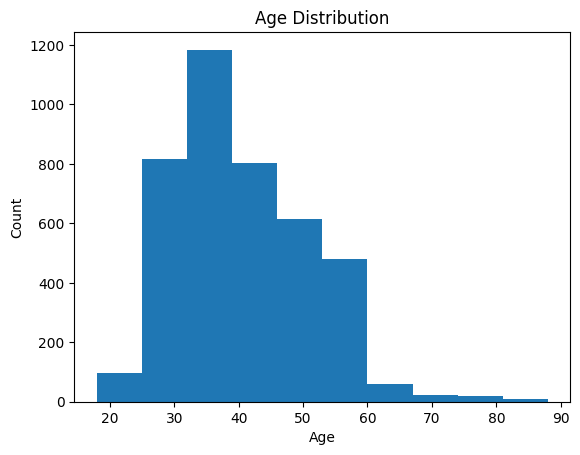

In [ ]:
plt.figure()
plt.hist(df["age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


The histogram illustrates the distribution of clients’ ages in the dataset. Each bar represents the number of clients within a specific age range. From this visualization, we can observe which age groups are more common among the bank’s clients. For example, most clients appear to be in the middle age range, while very young or very old clients are fewer. This helps in understanding the demographic profile of the clients.

### Bar Chart

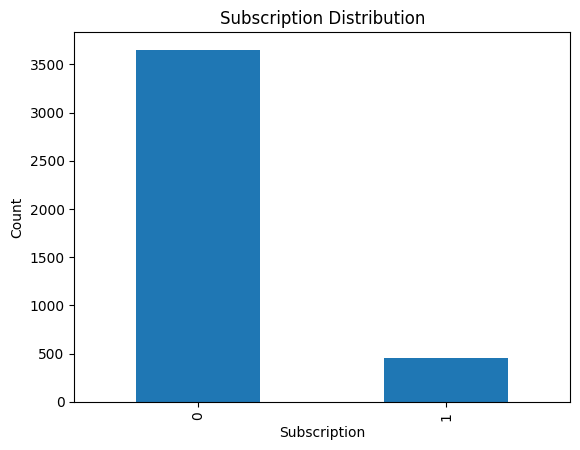

In [ ]:
plt.figure()
df["y"].value_counts().plot(kind="bar")
plt.title("Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()


The bar chart shows the number of clients who subscribed to the term deposit versus those who did not. Each bar represents a category of the target variable (y). From this visualization, it is clear that most clients did not subscribe to the term deposit. This provides insight into the overall success of the marketing campaign and helps identify potential areas for improvement.


### Scatter Plot

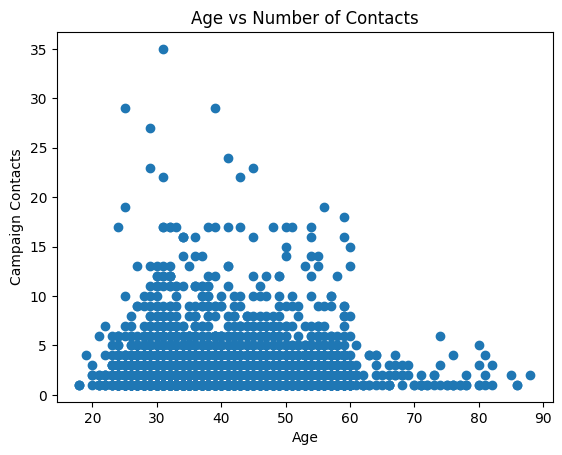

In [ ]:
plt.figure()
plt.scatter(df["age"], df["campaign"])
plt.title("Age vs Number of Contacts")
plt.xlabel("Age")
plt.ylabel("Campaign Contacts")
plt.show()


The scatter plot illustrates the relationship between clients’ ages and the number of times they were contacted during the marketing campaign. Each point represents a single client. This visualization helps identify patterns, such as whether certain age groups were contacted more frequently. It provides insight into how the campaign targeted different demographics and can be useful for future campaign planning.
